In [1]:
# %%
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

In [2]:
# %%
# Training data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

# Validation data preprocessing
val_datagen = ImageDataGenerator(
    rescale=1./255
)

In [3]:
train_data = train_datagen.flow_from_directory(
    r"C:\Users\farou\Downloads\ANNproj\Cervical-Fracture\cervical fracture\train",
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

val_data = val_datagen.flow_from_directory(
    r"C:\Users\farou\Downloads\ANNproj\Cervical-Fracture\cervical fracture\val",
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 3800 images belonging to 2 classes.
Found 400 images belonging to 2 classes.


In [4]:
# %%
# Load DenseNet121 model
base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pretrained layers
base_model.trainable = False

# Create model
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

In [5]:
# %%
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   


 densenet121 (Functional)    (None, 7, 7, 1024)        7037504   
                                                                 
 global_average_pooling2d (  (None, 1024)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dropout (Dropout)           (None, 1024)              0         
                                                                 
 dense (Dense)               (None, 1)                 1025      
                                                                 
Total params: 7038529 (26.85 MB)
Trainable params: 1025 (4.00 KB)
Non-trainable params: 7037504 (26.85 MB)
_________________________________________________________________


In [ ]:
import os

train_path = r"C:\Users\farou\Downloads\ANNproj\Cervical-Fracture\cervical fracture\train"
val_path = r"C:\Users\farou\Downloads\ANNproj\Cervical-Fracture\cervical fracture\val"

train_ids = set()
val_ids = set()

# Read train IDs
for category in ['fracture', 'normal']:
    
    folder = os.path.join(train_path, category)
    
    for file in os.listdir(folder):
        
        patient_id = file.split(" ")[0]
        train_ids.add(patient_id)

# Read validation IDs
for category in ['fracture', 'normal']:
    
    folder = os.path.join(val_path, category)
    
    for file in os.listdir(folder):
        
        patient_id = file.split(" ")[0]
        val_ids.add(patient_id)

# Find overlap
overlap = train_ids.intersection(val_ids)

print("Number of overlapping patient IDs:", len(overlap))

print("Some overlapping IDs:")
print(list(overlap)[:10])

In [6]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [7]:
# %%
import scipy
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5,
    callbacks=[early_stop]
)

Epoch 1/5


119/119 [==============================] - 239s 2s/step - loss: 0.5472 - accuracy: 0.7274 - val_loss: 0.3280 - val_accuracy: 0.9700
Epoch 2/5
119/119 [==============================] - 276s 2s/step - loss: 0.2540 - accuracy: 0.9029 - val_loss: 0.2049 - val_accuracy: 1.0000
Epoch 3/5
119/119 [==============================] - 266s 2s/step - loss: 0.1821 - accuracy: 0.9353 - val_loss: 0.1670 - val_accuracy: 1.0000
Epoch 4/5
119/119 [==============================] - 307s 3s/step - loss: 0.1589 - accuracy: 0.9447 - val_loss: 0.1278 - val_accuracy: 1.0000
Epoch 5/5
119/119 [==============================] - 253s 2s/step - loss: 0.1347 - accuracy: 0.9521 - val_loss: 0.1029 - val_accuracy: 1.0000


In [8]:
# Unfreeze last layers
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

In [9]:
model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [10]:
fine_tune_history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=3
)

Epoch 1/3
119/119 [==============================] - 447s 4s/step - loss: 0.2950 - accuracy: 0.8711 - val_loss: 0.1112 - val_accuracy: 0.9725
Epoch 2/3
119/119 [==============================] - 439s 4s/step - loss: 0.1970 - accuracy: 0.9171 - val_loss: 0.1049 - val_accuracy: 0.9650
Epoch 3/3
119/119 [==============================] - 436s 4s/step - loss: 0.1431 - accuracy: 0.9442 - val_loss: 0.0840 - val_accuracy: 0.9775


In [11]:
# %%
loss, accuracy = model.evaluate(val_data)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

13/13 [==============================] - 38s 3s/step - loss: 0.0840 - accuracy: 0.9775
Validation Loss: 0.08400381356477737
Validation Accuracy: 0.9775000214576721


In [12]:
from tensorflow.keras.optimizers import RMSprop
# Reload fresh DenseNet
base_model_rms = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model_rms.trainable = False
# Create second model
model_rms = Sequential([
    base_model_rms,
    GlobalAveragePooling2D(),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Compile with RMSprop
model_rms.compile(
    optimizer=RMSprop(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train
history_rms = model_rms.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
119/119 [==============================] - 398s 3s/step - loss: 0.4660 - accuracy: 0.7700 - val_loss: 0.2759 - val_accuracy: 0.9625
Epoch 2/5
119/119 [==============================] - 246s 2s/step - loss: 0.2262 - accuracy: 0.9076 - val_loss: 0.1661 - val_accuracy: 0.9975
Epoch 3/5
119/119 [==============================] - 192s 2s/step - loss: 0.1554 - accuracy: 0.9450 - val_loss: 0.1255 - val_accuracy: 1.0000
Epoch 4/5
119/119 [==============================] - 205s 2s/step - loss: 0.1257 - accuracy: 0.9555 - val_loss: 0.1026 - val_accuracy: 1.0000
Epoch 5/5
119/119 [==============================] - 218s 2s/step - loss: 0.1105 - accuracy: 0.9624 - val_loss: 0.0841 - val_accuracy: 1.0000


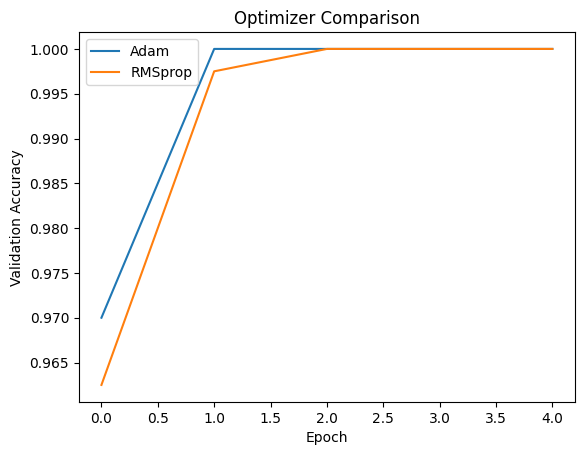

In [13]:
plt.plot(history.history['val_accuracy'])
plt.plot(history_rms.history['val_accuracy'])

plt.title("Optimizer Comparison")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")

plt.legend(['Adam', 'RMSprop'])

plt.show()

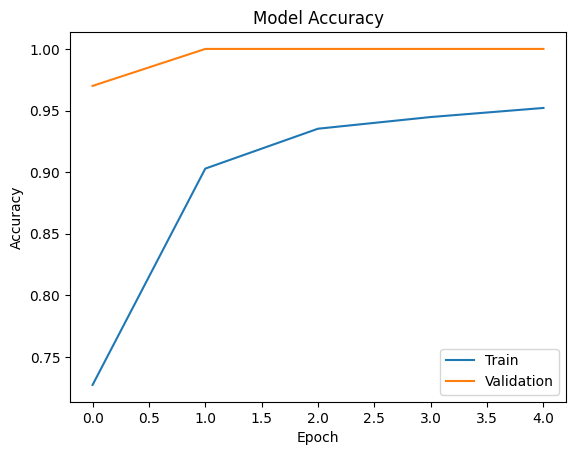

In [14]:
# %%
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(['Train', 'Validation'])

plt.show()

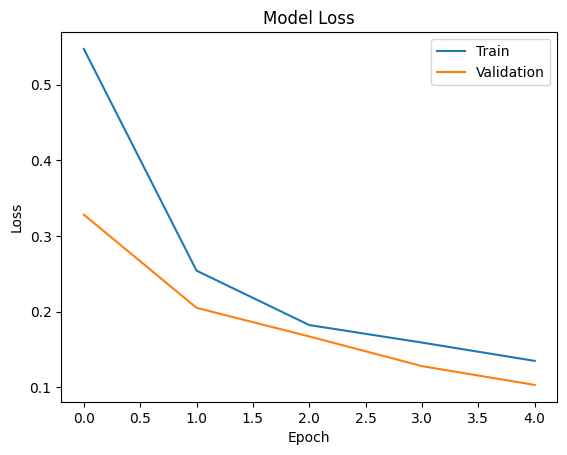

In [15]:
# %%
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(['Train', 'Validation'])

plt.show()

13/13 [==============================] - 21s 2s/step


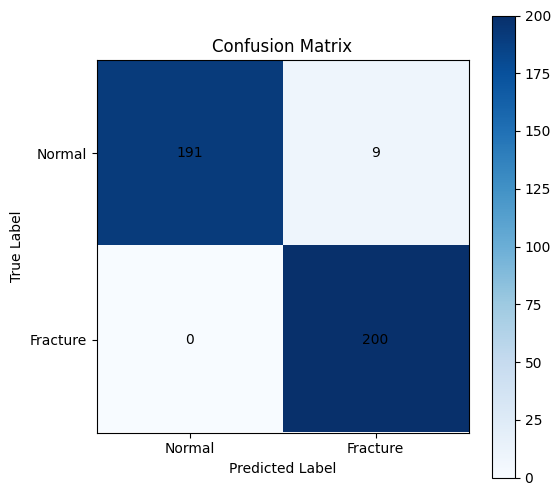

In [16]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Predict classes
predictions = model.predict(val_data)
predictions = (predictions > 0.5).astype(int)

# True labels
true_labels = val_data.classes

# Create confusion matrix
cm = confusion_matrix(true_labels, predictions)

# Plot confusion matrix
plt.figure(figsize=(6,6))

plt.imshow(cm, cmap='Blues')

plt.title("Confusion Matrix")
plt.colorbar()

classes = ['Normal', 'Fracture']

tick_marks = np.arange(len(classes))

plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Add numbers inside boxes
for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, cm[i, j],
                 ha='center',
                 va='center',
                 color='black')

plt.show()

In [17]:
from sklearn.metrics import classification_report

print(classification_report(true_labels, predictions))

              precision    recall  f1-score   support

           0       1.00      0.95      0.98       200
           1       0.96      1.00      0.98       200

    accuracy                           0.98       400
   macro avg       0.98      0.98      0.98       400
weighted avg       0.98      0.98      0.98       400



In [18]:
from sklearn.metrics import f1_score

f1 = f1_score(true_labels, predictions)
print("F1 Score:", f1)

F1 Score: 0.9779951100244498


In [19]:
from sklearn.metrics import roc_auc_score

# use probabilities, NOT thresholded predictions
probs = model.predict(val_data)

auc = roc_auc_score(true_labels, probs)
print("ROC-AUC:", auc)

13/13 [==============================] - 20s 2s/step
ROC-AUC: 0.9999999999999999


1/1 [==============================] - 3s 3s/step


C:\Users\farou\AppData\Local\Temp\ipykernel_35448\1637796532.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_label = class_names[int(preds[i])]


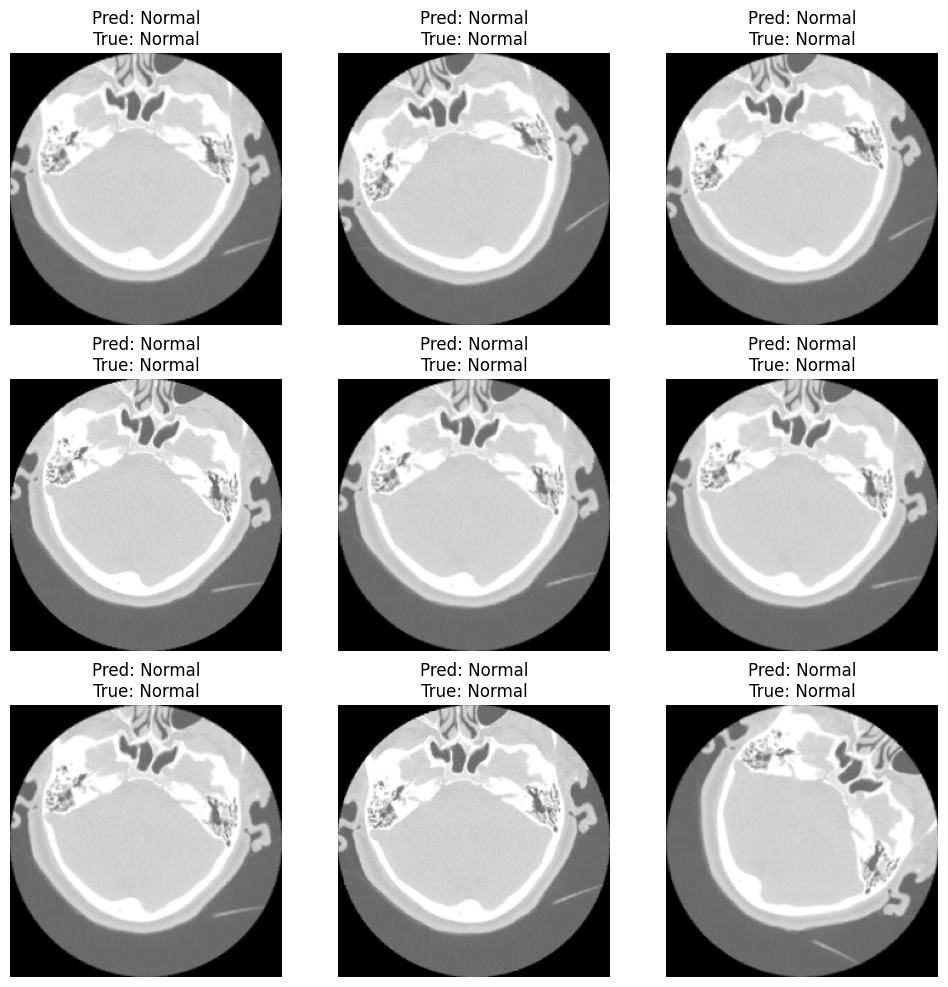

In [20]:
class_names = ['Normal', 'Fracture']

images, labels = next(val_data)

preds = model.predict(images)
preds = (preds > 0.5).astype(int)

plt.figure(figsize=(12,12))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    pred_label = class_names[int(preds[i])]
    true_label = class_names[int(labels[i])]

    plt.title(f"Pred: {pred_label}\nTrue: {true_label}")

    plt.axis('off')

plt.show()

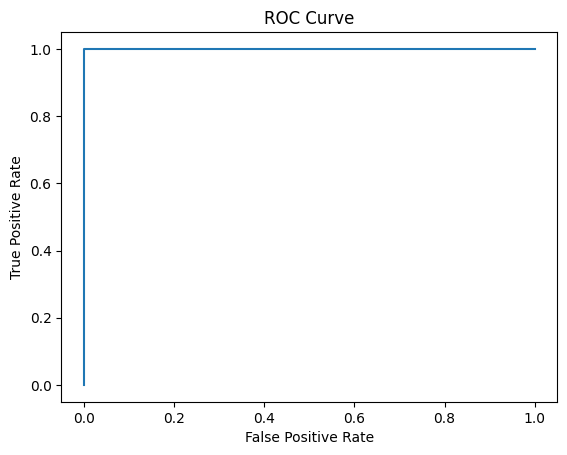

In [21]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(true_labels, probs)

plt.plot(fpr, tpr)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

1/1 [==============================] - 0s 49ms/step


IndexError: index 3 is out of bounds for axis 3 with size 3

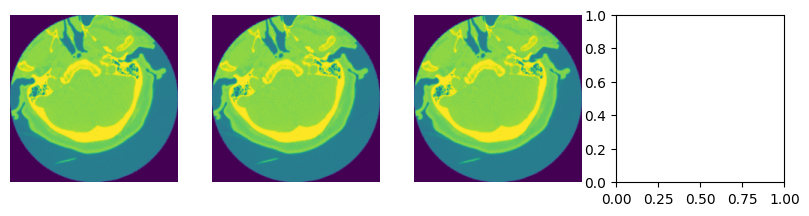

In [22]:
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np

img_path = r"C:\Users\farou\Downloads\ANNproj\Cervical-Fracture\cervical fracture\train\fracture\CSFDV1B10 (18)-rotated3-rotated2.png"

# Load image
img = image.load_img(img_path, target_size=(224,224))

# Convert to array
img_array = image.img_to_array(img)

# Expand dimensions
img_array = np.expand_dims(img_array, axis=0)

# Normalize
img_array = img_array / 255.0

# Extract feature maps
layer_outputs = [layer.output for layer in base_model.layers[:6]]

feature_model = Model(
    inputs=base_model.input,
    outputs=layer_outputs
)

feature_maps = feature_model.predict(img_array)

# Plot feature maps
for layer_num, fmap in enumerate(feature_maps):

    plt.figure(figsize=(10,10))

    for i in range(16):

        plt.subplot(4,4,i+1)

        plt.imshow(fmap[0, :, :, i], cmap='viridis')

        plt.axis('off')

    plt.suptitle(f"Feature Maps - Layer {layer_num+1}")

    plt.show()

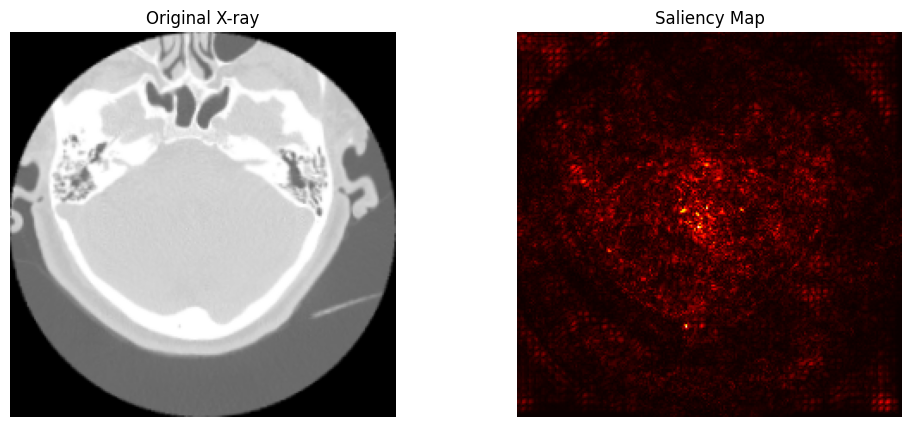

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
# =========================
# Load Image
# =========================

img_path = r"C:\Users\farou\Downloads\ANNproj\Cervical-Fracture\cervical fracture\val\fracture\CSFDV1B10 (1)-rotated1-rotated1.png"

img = image.load_img(img_path, target_size=(224,224))

img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

img_array = img_array / 255.0

# Convert to tensor
input_image = tf.convert_to_tensor(img_array)

# =========================
# Create Saliency Map
# =========================

with tf.GradientTape() as tape:

    tape.watch(input_image)

    prediction = model(input_image)

# Compute gradients
grads = tape.gradient(prediction, input_image)

# Convert gradients to absolute values
saliency = tf.reduce_max(tf.abs(grads), axis=-1)[0]

# =========================
# Plot Results
# =========================

plt.figure(figsize=(12,5))

# Original Image
plt.subplot(1,2,1)

plt.imshow(img)

plt.title("Original X-ray")

plt.axis('off')

# Saliency Map
plt.subplot(1,2,2)

plt.imshow(saliency, cmap='hot')

plt.title("Saliency Map")

plt.axis('off')

plt.show()

1/1 [==============================] - 1s 1s/step


C:\Users\farou\AppData\Local\Temp\ipykernel_35448\3830002028.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_label = class_names[int(predictions[i])]


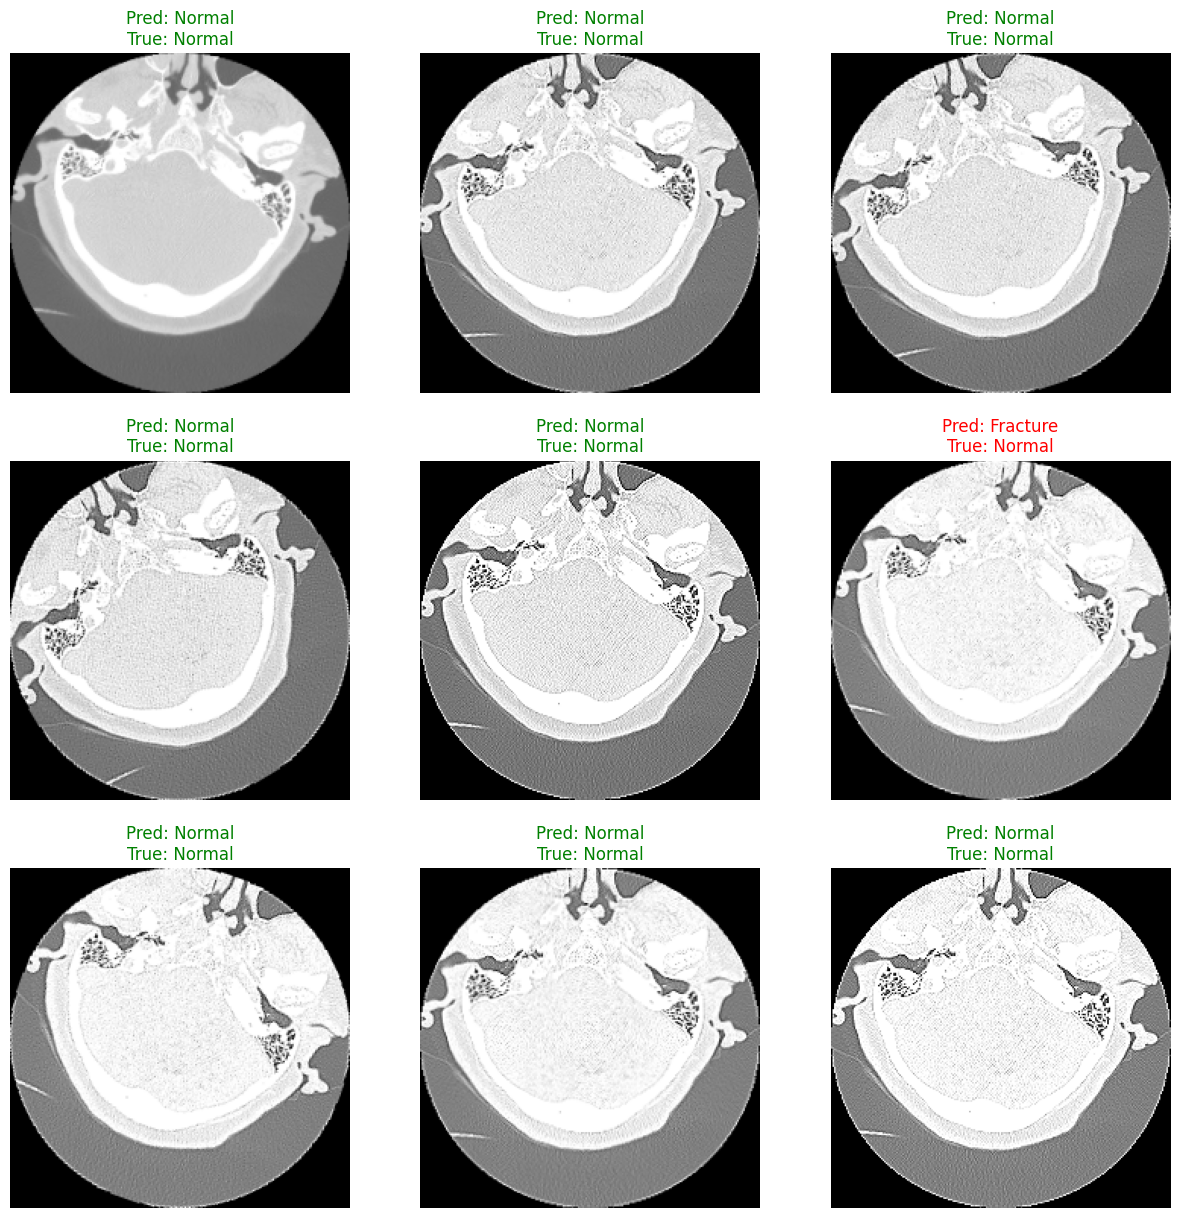

In [23]:
images, labels = next(val_data)

predictions = model.predict(images)
predictions = (predictions > 0.5).astype(int)

class_names = ['Normal', 'Fracture']

plt.figure(figsize=(15,15))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    pred_label = class_names[int(predictions[i])]
    true_label = class_names[int(labels[i])]

    if pred_label == true_label:
        title_color = 'green'
    else:
        title_color = 'red'

    plt.title(
        f"Pred: {pred_label}\nTrue: {true_label}",
        color=title_color
    )

    plt.axis('off')

plt.show()